In [65]:
print('Radha!')

Radha!


In [66]:
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from  dotenv import load_dotenv
from typing import Literal, TypedDict
from langgraph.graph import StateGraph, START, END

In [67]:
load_dotenv()
model = ChatOpenAI()

In [ ]:
class SentimentSchema(BaseModel):
    sentiment : Literal['positive','negative'] = Field(description='Return sentiment of the review either negative, positive')
    tone :  


In [69]:
structure_model = model.with_structured_output(SentimentSchema)

d:\LangGraph\venv\Lib\site-packages\langchain_openai\chat_models\base.py:2471: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [70]:
class ReviewState(TypedDict):
    
    review : str
    sentiment : Literal['positive','negative']
    dianogsis : dict
    response : str

In [71]:
def find_sentiment(state: ReviewState) -> str:
    
    prompt = f'For the following review find out the sentiment \n{state['review']}'
    sentiment = structure_model.invoke(prompt).sentiment

    return{
        'sentiment': sentiment
    }


In [72]:
def route_sentiment(state: ReviewState)->str:
    return state['sentiment']

In [73]:
def positive_reply(state: ReviewState):

    prompt = f''' we have to reply to the customers:
    You write a short and clear positive thanks for on the given\n{state['review']}'''
    response = model.invoke(prompt).content

    return{
        'response': response
    }

In [74]:
def negative_reply(state: ReviewState):

    prompt = f'You write a short appolies for on the given\n{state['review']}'
    response = model.invoke(prompt).content 
    return{
        'response': response
    }

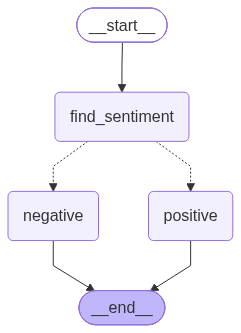

In [75]:
# create node
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive', positive_reply)
graph.add_node('negative', negative_reply)

# add edges
graph.add_edge(START, 'find_sentiment')
graph.add_conditional_edges(
    'find_sentiment',
    route_sentiment,
    {
        'positive': 'positive',
        'negative': 'negative'
    },
)
graph.add_edge('positive', END)
graph.add_edge('negative', END)

# compile graph
graph.compile()


In [76]:
workflow = graph.compile()
intial_state = {
    'review':'I like this product so much because it is build quality is so perfect'
}

output = workflow.invoke(intial_state)
print(output['response'])


Thank you for your positive feedback! We're thrilled to hear that you love the product's quality. Your satisfaction is our top priority.
